# Exploration of Calorimetry

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

from utils import load_root_file

## Study EDM4HEP object

In [13]:
# edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/events3.edm4hep.root"
# edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/acts/thirdparty/OpenDataDetector/test_calo.edm4hep.root"
# edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/acts/thirdparty/OpenDataDetector/test_calo2.edm4hep.root"
# edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/pythia_events3.edm4hep.root" # High pileup
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/pythia_events4.edm4hep.root" # Low pileup
f = uproot.open(edm4hep_file)
events = f["events"]
print(f.keys())

['events;1', 'runs;1', 'metadata;1', 'podio_metadata;1']


In [14]:
# Read ECal Barrel hits
ecal_barrel = {
    "energy": events["ECalBarrelCollection/ECalBarrelCollection.energy"].array(),
    "pos_x": events["ECalBarrelCollection/ECalBarrelCollection.position.x"].array(),
    "pos_y": events["ECalBarrelCollection/ECalBarrelCollection.position.y"].array(),
    "pos_z": events["ECalBarrelCollection/ECalBarrelCollection.position.z"].array(),
}
ecal_endcap = {
    "energy": events["ECalEndcapCollection/ECalEndcapCollection.energy"].array(),
    "pos_x": events["ECalEndcapCollection/ECalEndcapCollection.position.x"].array(),
    "pos_y": events["ECalEndcapCollection/ECalEndcapCollection.position.y"].array(),
    "pos_z": events["ECalEndcapCollection/ECalEndcapCollection.position.z"].array(),
}
hcal_barrel = {
    "energy": events["HCalBarrelCollection/HCalBarrelCollection.energy"].array(),
    "pos_x": events["HCalBarrelCollection/HCalBarrelCollection.position.x"].array(),
    "pos_y": events["HCalBarrelCollection/HCalBarrelCollection.position.y"].array(),
    "pos_z": events["HCalBarrelCollection/HCalBarrelCollection.position.z"].array(),
}
hcal_endcap = {
    "energy": events["HCalEndcapCollection/HCalEndcapCollection.energy"].array(),
    "pos_x": events["HCalEndcapCollection/HCalEndcapCollection.position.x"].array(),
    "pos_y": events["HCalEndcapCollection/HCalEndcapCollection.position.y"].array(),
    "pos_z": events["HCalEndcapCollection/HCalEndcapCollection.position.z"].array(),
}

# Read tracker hits, which are stored in many collections. We need to iterate 
# over all collection names that have *pixel* or *strip* in the name.
tracker_collections = list(set([
    k.split('/')[0] for k in events.keys() 
    if ("Pixel" in k or "Strip" in k) 
    and not "MCParticle" in k
]))
print(f"Tracker collections: {tracker_collections}")
tracker_hits = {}
for collection in tracker_collections:
    tracker_hits[collection] = {
        "pos_x": events[f"{collection}/{collection}.position.x"].array(),
        "pos_y": events[f"{collection}/{collection}.position.y"].array(),
        "pos_z": events[f"{collection}/{collection}.position.z"].array(),
    }

# Print some basic info
print("\nECal Barrel Statistics:")
print(f"Number of events: {len(ecal_barrel['energy'])}")
print(f"Total hits: {sum(ak.num(ecal_barrel['energy']))}")
print(f"Average hits per event: {np.mean(ak.num(ecal_barrel['energy'])):.1f}")
print(f"Total energy deposited: {ak.sum(ecal_barrel['energy']):.2f} GeV")

print("\nECal Endcap Statistics:")
print(f"Number of events: {len(ecal_endcap['energy'])}")
print(f"Total hits: {sum(ak.num(ecal_endcap['energy']))}")
print(f"Average hits per event: {np.mean(ak.num(ecal_endcap['energy'])):.1f}")
print(f"Total energy deposited: {ak.sum(ecal_endcap['energy']):.2f} GeV")

print("\nHCal Barrel Statistics:")
print(f"Number of events: {len(hcal_barrel['energy'])}")
print(f"Total hits: {sum(ak.num(hcal_barrel['energy']))}")
print(f"Average hits per event: {np.mean(ak.num(hcal_barrel['energy'])):.1f}")
print(f"Total energy deposited: {ak.sum(hcal_barrel['energy']):.2f} GeV")

print("\nHCal Endcap Statistics:")
print(f"Number of events: {len(hcal_endcap['energy'])}")
print(f"Total hits: {sum(ak.num(hcal_endcap['energy']))}")
print(f"Average hits per event: {np.mean(ak.num(hcal_endcap['energy'])):.1f}")
print(f"Total energy deposited: {ak.sum(hcal_endcap['energy']):.2f} GeV")

print("\nTracker Hits Statistics:")
for collection in tracker_hits.keys():
    print(f"\n{collection}:")
    print(f"Number of events: {len(tracker_hits[collection]['pos_x'])}")
    print(f"Total hits: {sum(ak.num(tracker_hits[collection]['pos_x']))}")
    print(f"Average hits per event: {np.mean(ak.num(tracker_hits[collection]['pos_x'])):.1f}")

# Print total number of hits across all collections
total_hits = sum([ak.num(v['pos_x']) for v in tracker_hits.values()])
print(f"Total hits: {sum(total_hits)}")



Tracker collections: ['PixelBarrelReadout', 'LongStripEndcapReadout', 'ShortStripEndcapReadout', 'ShortStripBarrelReadout', 'LongStripBarrelReadout', 'PixelEndcapReadout']

ECal Barrel Statistics:
Number of events: 3
Total hits: 1019
Average hits per event: 339.7
Total energy deposited: 0.40 GeV

ECal Endcap Statistics:
Number of events: 3
Total hits: 2227
Average hits per event: 742.3
Total energy deposited: 0.92 GeV

HCal Barrel Statistics:
Number of events: 3
Total hits: 258
Average hits per event: 86.0
Total energy deposited: 0.04 GeV

HCal Endcap Statistics:
Number of events: 3
Total hits: 2618
Average hits per event: 872.7
Total energy deposited: 0.78 GeV

Tracker Hits Statistics:

PixelBarrelReadout:
Number of events: 3
Total hits: 209
Average hits per event: 69.7

LongStripEndcapReadout:
Number of events: 3
Total hits: 77
Average hits per event: 25.7

ShortStripEndcapReadout:
Number of events: 3
Total hits: 216
Average hits per event: 72.0

ShortStripBarrelReadout:
Number of ev

In [6]:
# Function to read a calorimeter collection
def read_calo_collection(name):
    return {
        "pos_x": events[f"{name}/{name}.position.x"].array(),
        "pos_y": events[f"{name}/{name}.position.y"].array(),
        "pos_z": events[f"{name}/{name}.position.z"].array(),
    }

# Read all collections
collections = {
    "ECal Barrel": read_calo_collection("ECalBarrelCollection"),
    "ECal Endcap": read_calo_collection("ECalEndcapCollection"),
    "HCal Barrel": read_calo_collection("HCalBarrelCollection"),
    "HCal Endcap": read_calo_collection("HCalEndcapCollection"),
    **tracker_hits
}

# Create plots
fig = plt.figure(figsize=(20, 15))

# Create a colormap for events
n_events = len(collections["ECal Barrel"]["pos_x"])
event_colors = plt.cm.rainbow(np.linspace(0, 1, n_events))

# 3D visualization
ax1 = fig.add_subplot(221, projection='3d')
for event_idx, event_color in enumerate(event_colors):
    for name, coll in collections.items():
        x = coll['pos_x'][event_idx]
        y = coll['pos_y'][event_idx]
        z = coll['pos_z'][event_idx]
        # If collection is tracker, use marker='x'
        marker = 'x' if "Pixel" in name or "Strip" in name else '.'
        scatter = ax1.scatter(x, y, z, c=[event_color], s=1, alpha=0.6, 
                            label=f"Event {event_idx}" if name == "ECal Barrel" else "",
                            marker=marker)
ax1.set_xlabel('x [mm]')
ax1.set_ylabel('y [mm]')
ax1.set_zlabel('z [mm]')
ax1.set_title('3D View of Calorimeter Hits')

# R-z projection
ax2 = fig.add_subplot(222)
for event_idx, event_color in enumerate(event_colors):
    for name, coll in collections.items():
        x = coll['pos_x'][event_idx]
        y = coll['pos_y'][event_idx]
        z = coll['pos_z'][event_idx]
        r = np.sqrt(x**2 + y**2)
        # If collection is tracker, use marker='x'
        marker = 'x' if "Pixel" in name or "Strip" in name else '.'
        scatter = ax2.scatter(z, r, c=[event_color], s=1, alpha=0.6,
                            label=f"Event {event_idx}" if name == "ECal Barrel" else "",
                            marker=marker)
ax2.set_xlabel('z [mm]')
ax2.set_ylabel('r [mm]')
ax2.set_title('R-z Projection')

# x-y projection
ax3 = fig.add_subplot(223)
for event_idx, event_color in enumerate(event_colors):
    for name, coll in collections.items():
        x = coll['pos_x'][event_idx]
        y = coll['pos_y'][event_idx]
        # If collection is tracker, use marker='x'
        marker = 'x' if "Pixel" in name or "Strip" in name else '.'
        scatter = ax3.scatter(x, y, c=[event_color], s=1, alpha=0.6,
                            label=f"Event {event_idx}" if name == "ECal Barrel" else "",
                            marker=marker)
ax3.set_xlabel('x [mm]')
ax3.set_ylabel('y [mm]')
ax3.set_title('x-y Projection')


plt.tight_layout()
plt.savefig('calorimeter_hits_events_pythia2.png', dpi=300, bbox_inches='tight')
plt.close()

# Print statistics per event
for event_idx in range(n_events):
    print(f"\nEvent {event_idx} Statistics:")
    print("-" * 50)
    for name, coll in collections.items():
        print(f"\n{name}:")
        n_hits = len(coll['pos_x'][event_idx])
        if n_hits > 0:
            print(f"Total hits: {n_hits}")
        else:
            print("No hits in this collection")


Event 0 Statistics:
--------------------------------------------------

ECal Barrel:
Total hits: 407

ECal Endcap:
Total hits: 1316

HCal Barrel:
Total hits: 161

HCal Endcap:
Total hits: 1464

PixelBarrelReadout:
Total hits: 87

LongStripEndcapReadout:
Total hits: 43

ShortStripEndcapReadout:
Total hits: 110

ShortStripBarrelReadout:
Total hits: 172

LongStripBarrelReadout:
Total hits: 40

PixelEndcapReadout:
Total hits: 127


In [16]:
name

'PixelBarrelReadout'

## Study ODD_Chain Outputs

In [123]:
odd_directory = Path("/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/odd_output_calo_tests")

tracker_hits = load_root_file(odd_directory / "simhits.root")
calo_hits = load_root_file(odd_directory / "calohits.root")


In [124]:
tracker_hits

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
entry,,,,,,,,,,,,,,,,,,,,,
0,0,1729382394349407488,4503599644147712,217.340408,139.330780,0.204725,258.267151,30.799894,19.830534,0.028227,...,0.0,0.0,0.0,-0.000055,-1,24,0,2,0,717
1,0,1729382531788364288,4503599644147712,317.792175,177.739090,-611.449829,49804.972656,-0.003100,0.004285,-0.011268,...,0.0,0.0,0.0,-0.000026,-1,24,0,4,0,730
2,0,1729382531788390144,4506898179162115,78.788322,-351.118469,964.142578,3092.425049,-0.000173,-0.000134,0.000122,...,0.0,0.0,0.0,-0.000205,-1,24,0,4,0,831
3,0,1729382531788406272,4506898179162115,176.221497,-311.594666,934.671997,3203.270020,-0.000031,0.000112,-0.000035,...,0.0,0.0,0.0,-0.000055,-1,24,0,4,0,894
4,0,1729382531788420096,4503599644147712,303.382599,194.831345,0.283111,360.657379,30.766008,19.881815,0.028009,...,0.0,0.0,0.0,-0.000059,-1,24,0,4,0,948
5,0,1729382531788436224,4503599644147712,330.407410,-147.148193,-16.655472,2536.427490,0.000003,-0.000136,0.000100,...,0.0,0.0,0.0,-0.000101,-1,24,0,4,0,1011
6,0,1729382669227375616,4503599644147712,460.417908,193.965454,897.676270,530279.437500,0.000118,-0.000009,0.000062,...,0.0,0.0,0.0,-0.000066,-1,24,0,6,0,956
7,0,1729382669227491840,4503599644147712,420.942688,270.994690,0.389986,500.733276,30.719477,19.952200,0.027455,...,0.0,0.0,0.0,-0.000053,-1,24,0,6,0,1410
8,0,1729382669227491840,4504699155906561,421.614624,269.464966,0.400143,500.471497,4.586040,2.928542,0.005994,...,0.0,0.0,0.0,-0.000058,-1,24,0,6,0,1410


In [125]:
calo_hits

,event_id,cell_id,x,y,z,energy
entry,,,,,,
0,0,197576943632,1067.289185,696.014893,-1.606029e-14,0.000814
1,0,197576976400,1071.954834,697.947449,-1.599997e-14,0.001338
2,0,201871976464,1074.668701,704.591736,-1.625793e-14,0.003560
3,0,201872009232,1079.334229,706.524292,-1.619760e-14,0.009214
4,0,201872042000,1083.999878,708.456848,-1.613727e-14,0.012251
...,...,...,...,...,...,...
1470,0,18446462431237595152,1029.794922,748.507874,-1.020000e+01,0.000070
1471,0,562795343110160,1022.547119,762.897522,5.100000e+00,0.000819
1472,0,1125856963518483,1377.090454,952.826416,9.000000e+01,0.000093


/tmp/ipykernel_168261/1319629246.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(tracker_x[tracker_hits["event_id"] == event_id], tracker_y[tracker_hits["event_id"] == event_id], c=color, label=f"Tracker Hits {event_id}", marker="x", alpha=0.5)
/tmp/ipykernel_168261/1319629246.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(calo_x[calo_hits["event_id"] == event_id], calo_y[calo_hits["event_id

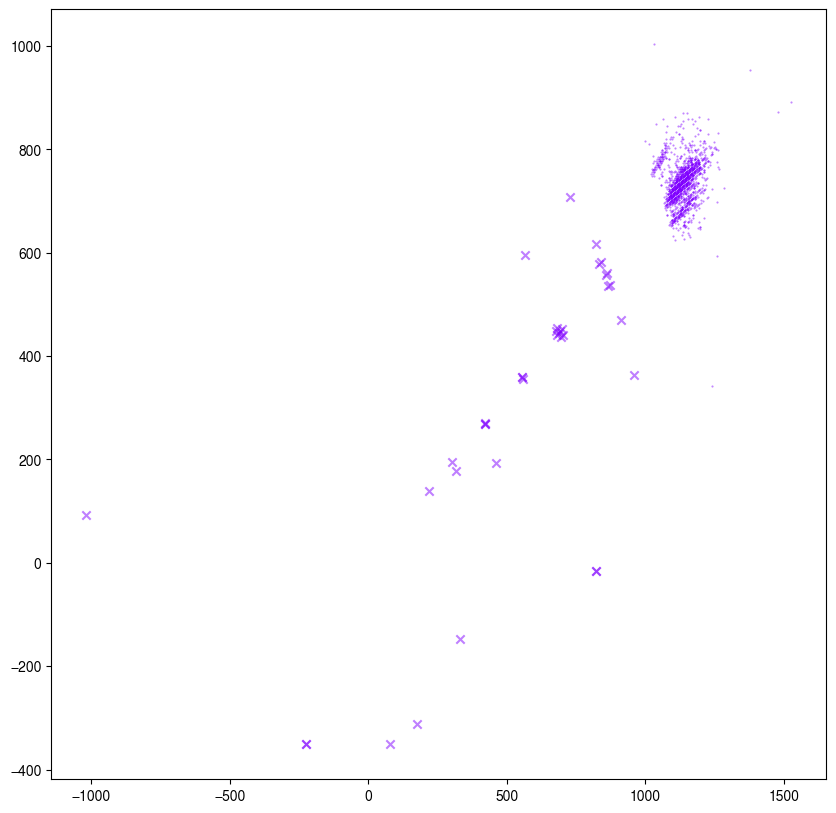

/tmp/ipykernel_168261/1319629246.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(tracker_x[tracker_hits["event_id"] == event_id], tracker_y[tracker_hits["event_id"] == event_id], tracker_z[tracker_hits["event_id"] == event_id], c=color, label=f"Tracker Hits {event_id}", marker="x", alpha=0.5)
/tmp/ipykernel_168261/1319629246.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(calo_x[calo_hits["eve

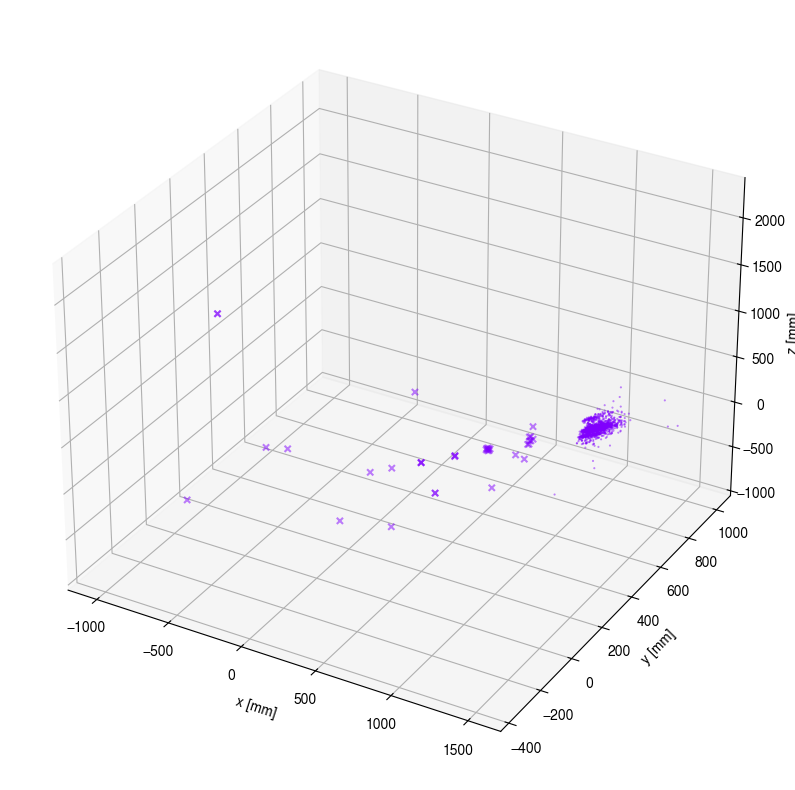

In [126]:
tracker_x, tracker_y, tracker_z = tracker_hits["tx"], tracker_hits["ty"], tracker_hits["tz"]
calo_x, calo_y, calo_z = calo_hits["x"], calo_hits["y"], calo_hits["z"]

# Plot all hits, colored by event_id
event_ids = set(tracker_hits["event_id"]) | set(calo_hits["event_id"])
colors = plt.cm.rainbow(np.linspace(0, 1, len(event_ids)))
plt.figure(figsize=(10, 10))
for event_id, color in zip(event_ids, colors):
    plt.scatter(tracker_x[tracker_hits["event_id"] == event_id], tracker_y[tracker_hits["event_id"] == event_id], c=color, label=f"Tracker Hits {event_id}", marker="x", alpha=0.5)
    plt.scatter(calo_x[calo_hits["event_id"] == event_id], calo_y[calo_hits["event_id"] == event_id], c=color, label=f"Calorimeter Hits {event_id}", marker=".", s=1, alpha=0.5)
plt.show()

# Plot the tracker hits in 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
for event_id, color in zip(event_ids, colors):
    ax.scatter(tracker_x[tracker_hits["event_id"] == event_id], tracker_y[tracker_hits["event_id"] == event_id], tracker_z[tracker_hits["event_id"] == event_id], c=color, label=f"Tracker Hits {event_id}", marker="x", alpha=0.5)
    ax.scatter(calo_x[calo_hits["event_id"] == event_id], calo_y[calo_hits["event_id"] == event_id], calo_z[calo_hits["event_id"] == event_id], c=color, label=f"Calorimeter Hits {event_id}", marker=".", alpha=0.5, s=1)
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_zlabel('z [mm]')
plt.show()